exe: C:\Users\am636\AppData\Local\miniconda3\envs\copperbelt\python.exe
CONDA_PREFIX: C:\Users\am636\AppData\Local\miniconda3\envs\copperbelt
PATH head: C:\Users\am636\AppData\Local\miniconda3\envs\copperbelt\Library\bin;C:\Users\am636\AppData\Local\miniconda3\envs\copperbelt\Scripts;C:\Users\am636\AppData\Local\miniconda3\envs\copperbelt;C:\WINDOWS\System32;C:\WINDOWS
numpy: 2.4.1
geopandas: 1.1.2
rasterio: 1.4.4
ROOT resolved to: C:\Users\am636\copperbelt_worldpop_smod


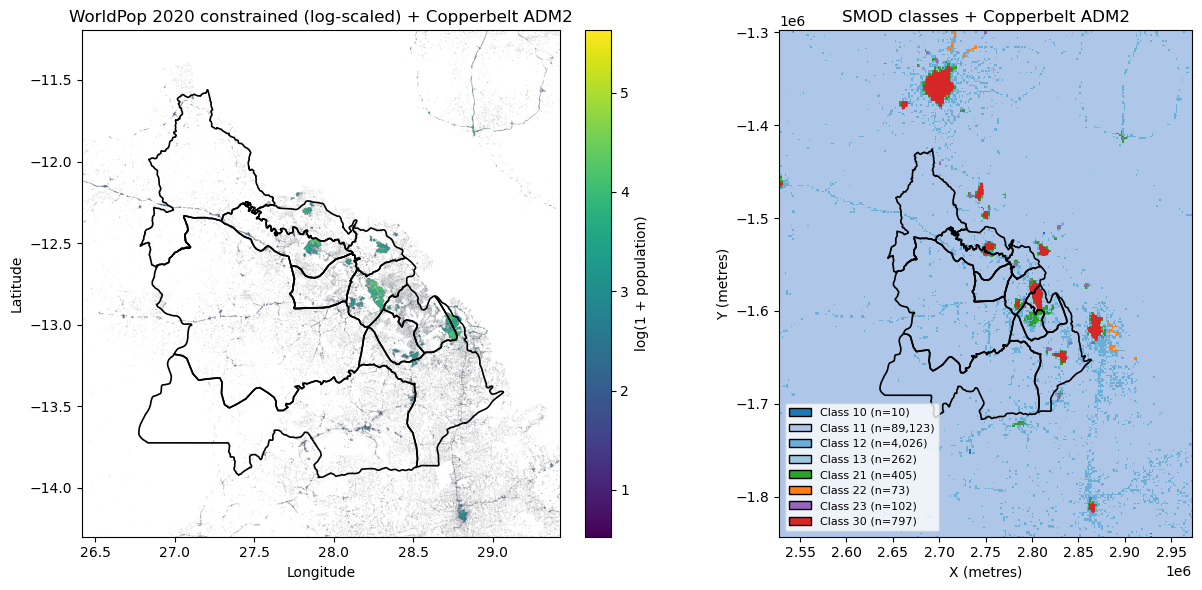


Saved artefacts:
JSON  -> C:\Users\am636\copperbelt_worldpop_smod\outputs\task1_00_sanity_check_metadata.json
CSV   -> C:\Users\am636\copperbelt_worldpop_smod\tables\task1_00_sanity_check_layers.csv
FIG   -> C:\Users\am636\copperbelt_worldpop_smod\figures\task1_00_layers_map.png


In [11]:
# ============================================================
# Task 1 — Metadata sanity-check + quick visual overlays
# ============================================================

from pathlib import Path
import json
from datetime import datetime, timezone
import sys, os

import numpy as np
import pandas as pd
import geopandas as gpd

# ---- Debug first (helps prove the kernel/env is correct) ----
print("exe:", sys.executable)
print("CONDA_PREFIX:", os.environ.get("CONDA_PREFIX"))
print("PATH head:", os.environ.get("PATH", "")[:300])

# Raster stack
import rasterio
import rasterio._base
from rasterio.windows import from_bounds

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgba
from matplotlib.patches import Patch

print("numpy:", np.__version__)
print("geopandas:", gpd.__version__)
print("rasterio:", rasterio.__version__)


# ----------------------------
# Project structure (ROOT auto)
# ----------------------------
ROOT = Path.cwd()
if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

# Guardrail: if this fails, you started Jupyter in the wrong folder
assert (ROOT / "data_raw").exists(), f"Wrong ROOT (data_raw not found): {ROOT.resolve()}"

DATA   = ROOT / "data_raw"
OUT    = ROOT / "outputs"
FIGDIR = ROOT / "figures"
TABDIR = ROOT / "tables"

for d in (OUT, FIGDIR, TABDIR):
    d.mkdir(parents=True, exist_ok=True)

print("ROOT resolved to:", ROOT.resolve())

PREFIX = "task1_"

adm2_path = DATA / "ZMB_adm2_gadm41_Copperbelt.shp"
pop_path  = DATA / "zmb_ppp_2020_constrained.tif"
smod_path = DATA / "GHS_SMOD_E2020_GLOBE_R2023A_54009_1000_V1_0_R11_C21.tif"

missing = [p for p in (adm2_path, pop_path, smod_path) if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing required input file(s) in data_raw:\n" + "\n".join(str(p) for p in missing)
    )

run_time_utc = datetime.now(timezone.utc).isoformat(timespec="seconds")


# ----------------------------
# Helpers
# ----------------------------
def raster_meta(path: Path) -> dict:
    with rasterio.open(path) as src:
        return {
            "path": str(path),
            "crs": str(src.crs),
            "width": int(src.width),
            "height": int(src.height),
            "bands": int(src.count),
            "dtype": list(src.dtypes),
            "nodata": src.nodata,
            "pixel_size": tuple(float(x) for x in src.res),
            "bounds": {
                "left": float(src.bounds.left),
                "bottom": float(src.bounds.bottom),
                "right": float(src.bounds.right),
                "top": float(src.bounds.top),
            },
            "driver": src.driver,
        }

def vector_meta(path: Path) -> dict:
    gdf = gpd.read_file(path)
    minx, miny, maxx, maxy = (float(x) for x in gdf.total_bounds)
    out = {
        "path": str(path),
        "crs": str(gdf.crs),
        "feature_count": int(len(gdf)),
        "geometry_type": str(gdf.geom_type.iloc[0]) if len(gdf) else None,
        "columns": list(gdf.columns),
        "bounds": {"minx": minx, "miny": miny, "maxx": maxx, "maxy": maxy},
    }
    if "NAME_2" in gdf.columns:
        out["NAME_2_sample"] = gdf["NAME_2"].head(10).tolist()
    return out

def read_window_for_polygon(raster_path: Path, poly_gdf: gpd.GeoDataFrame, pad: float = 0.0):
    """
    Reads a single-band raster window around polygon bounds.
    pad is in raster CRS units (degrees for EPSG:4326, metres for Mollweide).
    """
    with rasterio.open(raster_path) as src:
        r_crs = src.crs
        nodata = src.nodata

        gdf_r = poly_gdf.to_crs(r_crs)
        minx, miny, maxx, maxy = gdf_r.total_bounds
        minx -= pad; miny -= pad; maxx += pad; maxy += pad

        win = from_bounds(minx, miny, maxx, maxy, transform=src.transform)
        win = win.round_offsets().round_lengths()

        arr = src.read(1, window=win)
        transform = src.window_transform(win)
        return arr, transform, r_crs, nodata

def extent_from_transform(transform, width: int, height: int):
    left, top = transform * (0, 0)
    right, bottom = transform * (width, height)
    return [left, right, bottom, top]

def zoom_out_extent(extent, factor=0.3):
    """
    Expand extent by a given fraction on each side.
    extent = [left, right, bottom, top]
    factor = 0.08 means 8% zoom-out
    """
    left, right, bottom, top = extent
    dx = (right - left) * factor
    dy = (top - bottom) * factor
    return [left - dx, right + dx, bottom - dy, top + dy]


# ----------------------------
# Task 1A: write metadata artefacts
# ----------------------------
record = {
    "run_time_utc": run_time_utc,
    "project_root": str(ROOT.resolve()),
    "folders": {
        "data_raw": str(DATA.resolve()),
        "outputs": str(OUT.resolve()),
        "figures": str(FIGDIR.resolve()),
        "tables": str(TABDIR.resolve()),
    },
    "files": {
        "adm2": str(adm2_path.resolve()),
        "worldpop": str(pop_path.resolve()),
        "smod": str(smod_path.resolve()),
    },
    "layers": {
        "adm2": vector_meta(adm2_path),
        "worldpop": raster_meta(pop_path),
        "smod": raster_meta(smod_path),
    },
}

json_path = OUT / f"{PREFIX}00_sanity_check_metadata.json"
json_path.write_text(json.dumps(record, indent=2), encoding="utf-8")

rows = []
for layer_name, meta in record["layers"].items():
    if layer_name == "adm2":
        rows.append({
            "layer": "adm2",
            "type": "vector",
            "crs": meta["crs"],
            "feature_count": meta["feature_count"],
            "width": None,
            "height": None,
            "pixel_x": None,
            "pixel_y": None,
            "bands": None,
            "dtype": None,
            "nodata": None,
            "bounds": f'{meta["bounds"]["minx"]},{meta["bounds"]["miny"]},{meta["bounds"]["maxx"]},{meta["bounds"]["maxy"]}',
            "path": meta["path"],
        })
    else:
        rows.append({
            "layer": layer_name,
            "type": "raster",
            "crs": meta["crs"],
            "feature_count": None,
            "width": meta["width"],
            "height": meta["height"],
            "pixel_x": meta["pixel_size"][0],
            "pixel_y": meta["pixel_size"][1],
            "bands": meta["bands"],
            "dtype": ";".join(meta["dtype"]),
            "nodata": meta["nodata"],
            "bounds": f'{meta["bounds"]["left"]},{meta["bounds"]["bottom"]},{meta["bounds"]["right"]},{meta["bounds"]["top"]}',
            "path": meta["path"],
        })

csv_path = TABDIR / f"{PREFIX}00_sanity_check_layers.csv"
pd.DataFrame(rows).to_csv(csv_path, index=False)


# ----------------------------
# Task 1B: figure (WorldPop + SMOD + ADM2)
# ----------------------------
adm2 = gpd.read_file(adm2_path)

# ---- WorldPop (EPSG:4326): pad in degrees ----
pop_arr, pop_tr, pop_crs, pop_nodata = read_window_for_polygon(pop_path, adm2, pad=0.15)

# mask NoData / invalid
if pop_nodata is not None:
    pop_masked = np.ma.masked_where(pop_arr == pop_nodata, pop_arr)
else:
    pop_masked = np.ma.masked_invalid(pop_arr)

# Robust log-scaling WITHOUT np.ma.log1p (your numpy.ma lacks it)
pop_filled = pop_masked.filled(0)
pop_filled = np.clip(pop_filled, 0, None)
pop_logged = np.log1p(pop_filled)
pop_display = np.ma.array(pop_logged, mask=pop_masked.mask)

# extent + zoom-out
pop_extent = zoom_out_extent(
    extent_from_transform(pop_tr, pop_display.shape[1], pop_display.shape[0]),
    factor=0.08
)
adm2_pop = adm2.to_crs(pop_crs)

# ---- SMOD (Mollweide): pad in metres ----
smod_arr, smod_tr, smod_crs, smod_nodata = read_window_for_polygon(smod_path, adm2, pad=25_000)

smod_mask = np.zeros_like(smod_arr, dtype=bool)
if smod_nodata is not None:
    smod_mask |= (smod_arr == smod_nodata)
smod_mask |= (smod_arr == 0)  # background/unknown

# extent + zoom-out (must happen AFTER smod_tr exists)
smod_extent = zoom_out_extent(
    extent_from_transform(smod_tr, smod_arr.shape[1], smod_arr.shape[0]),
    factor=0.3
)
adm2_smod = adm2.to_crs(smod_crs)

# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
# UPDATED: show up to 12 SMOD L2 classes present in the window
# Select top-12 by frequency, THEN sort those selected codes numerically
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
MAX_SMOD_CLASSES = 12

vals_all, counts_all = np.unique(smod_arr[~smod_mask], return_counts=True)

# 1) top-12 by frequency
freq_order = np.argsort(counts_all)[::-1]
vals_top = vals_all[freq_order].astype(int)
counts_top = counts_all[freq_order].astype(int)
if len(vals_top) > MAX_SMOD_CLASSES:
    vals_top = vals_top[:MAX_SMOD_CLASSES]
    counts_top = counts_top[:MAX_SMOD_CLASSES]

# 2) sort numerically by code (10, 11, 12, ...)
num_order = np.argsort(vals_top)
vals = vals_top[num_order]
counts = counts_top[num_order]

# Map SMOD codes -> 1..K indices for plotting
code_to_idx = {int(code): i + 1 for i, code in enumerate(vals.tolist())}
smod_idx = np.zeros_like(smod_arr, dtype=np.int16)
for code, idx in code_to_idx.items():
    smod_idx[smod_arr == code] = idx

# Mask background/NoData + anything outside selected classes
smod_plot = np.ma.masked_where(smod_mask | (smod_idx == 0), smod_idx)

K = int(len(vals))

# ------------------------------------------------------------
# COLOUR CONTROL (pick ONE mode)
#   "custom_grouped"  -> recommended (enforces 10 blue; 21/22/23/30 distinct)
#   "tab20"           -> fallback, automatic
# ------------------------------------------------------------
PALETTE_MODE = "custom_grouped"

def build_colors_for_codes(codes_sorted):
    """
    Returns a list of RGBA colours (length = len(codes_sorted)),
    one per SMOD code in 'codes_sorted' order.
    """
    fixed = {
        10: "#1f77b4",  # blue (keep this)
        12: "#6baed6",  # lighter blue
        13: "#9ecae1",  # very light blue
        21: "#2ca02c",  # green
        22: "#ff7f0e",  # orange
        23: "#9467bd",  # purple
        30: "#d62728",  # red
    }

    if PALETTE_MODE == "tab20":
        cmap = plt.get_cmap("tab20", max(len(codes_sorted), 1))
        return [cmap(i) for i in range(len(codes_sorted))]

    tab = plt.get_cmap("tab20", 20)
    pool = [tab(i) for i in range(20)]

    used = []
    def take_from_pool():
        for c in pool:
            if c not in used:
                used.append(c)
                return c
        return pool[len(used) % len(pool)]

    out = []
    for code in codes_sorted:
        if int(code) in fixed:
            c = to_rgba(fixed[int(code)])
            out.append(c)
            used.append(c)
        else:
            out.append(take_from_pool())
    return out

# background first, then one colour per class index 1..K
bg = (0.85, 0.85, 0.85, 1.0)
class_colors = build_colors_for_codes(vals.tolist())
smod_cmap = ListedColormap([bg] + class_colors)

# bin edges for categorical indices: 0..K (index 0 = background)
smod_norm = BoundaryNorm(np.arange(0, K + 2) - 0.5, smod_cmap.N)
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
im0 = ax.imshow(pop_display, extent=pop_extent, origin="upper")
adm2_pop.boundary.plot(ax=ax, linewidth=1.2, color="black")
ax.set_title("WorldPop 2020 constrained (log-scaled) + Copperbelt ADM2")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
cbar0 = plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)
cbar0.set_label("log(1 + population)")

ax = axes[1]
ax.imshow(
    smod_plot,
    extent=smod_extent,
    origin="upper",
    cmap=smod_cmap,
    norm=smod_norm,
    interpolation="nearest",
)
adm2_smod.boundary.plot(ax=ax, linewidth=1.2, color="black")
ax.set_title("SMOD classes + Copperbelt ADM2")
ax.set_xlabel("X (metres)")
ax.set_ylabel("Y (metres)")

# Legend for the codes actually shown (sorted by code)
handles = []
for i, code in enumerate(vals.tolist(), start=1):
    handles.append(
        Patch(
            facecolor=smod_cmap(i),
            edgecolor="black",
            label=f"Class {code} (n={counts[i-1]:,})"
        )
    )
ax.legend(handles=handles, loc="lower left", frameon=True, fontsize=8)

plt.tight_layout()
map_path = FIGDIR / f"{PREFIX}00_layers_map.png"
plt.savefig(map_path, dpi=200, bbox_inches="tight")
plt.show()

print("\nSaved artefacts:")
print("JSON  ->", json_path.resolve())
print("CSV   ->", csv_path.resolve())
print("FIG   ->", map_path.resolve())
